        Date Country  Confirmed  Recovered  Deaths  Active
0 2021-01-01     USA        890       1519     154       0
1 2021-01-02     USA        768       1460     160       0
2 2021-01-03     USA        764       1387     157       0
3 2021-01-04     USA        872       1597     151       0
4 2021-01-05     USA        813       1568     150       0

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       300 non-null    datetime64[us]
 1   Country    300 non-null    str           
 2   Confirmed  300 non-null    int64         
 3   Recovered  300 non-null    int64         
 4   Deaths     300 non-null    int64         
 5   Active     300 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 14.2 KB
None

                      Date    Confirmed    Recovered      Deaths       Active
count                  300

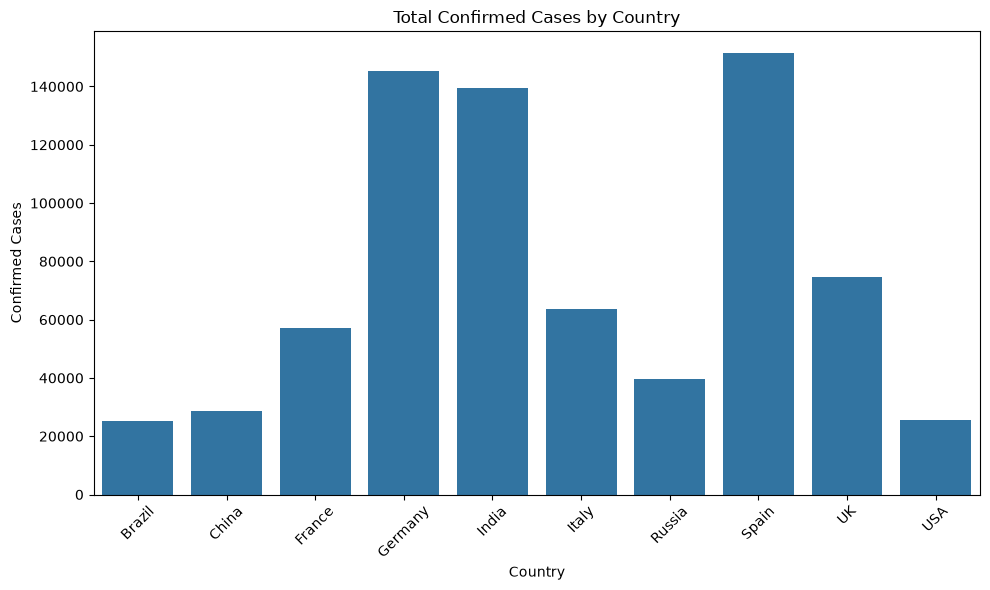

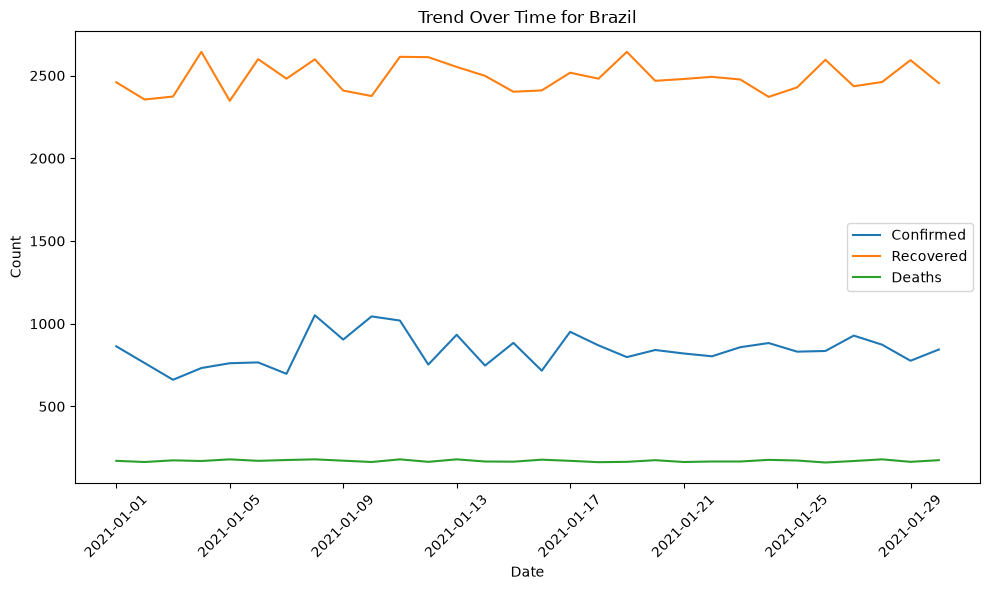

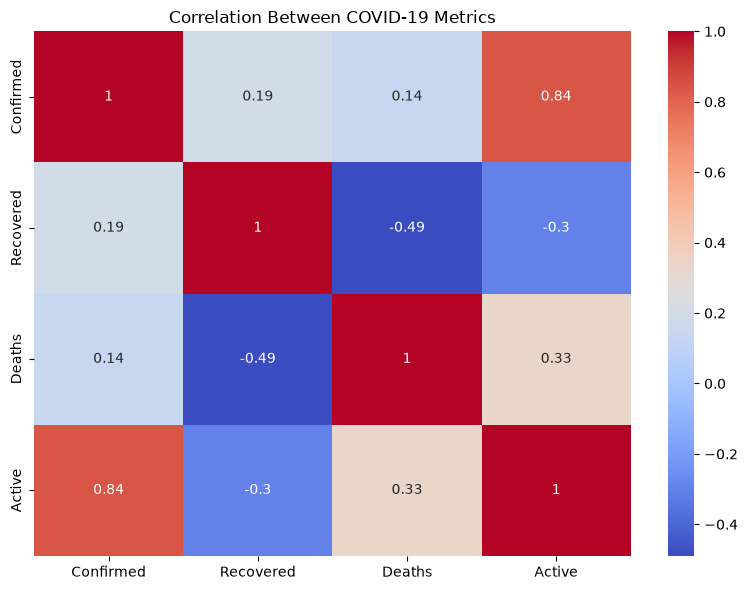

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("covid_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())
print()

country_totals = df.groupby("Country")[["Confirmed", "Recovered", "Deaths"]].sum()
print(country_totals)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_totals.index, y=country_totals["Confirmed"])
plt.xticks(rotation=45)
plt.title("Total Confirmed Cases by Country")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.tight_layout()
plt.show()

top_country=country_totals.index[0]
top_country_data=df[df["Country"]==top_country]

plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="Confirmed", data=top_country_data, label="Confirmed")
sns.lineplot(x="Date", y="Recovered", data=top_country_data, label="Recovered")
sns.lineplot(x="Date", y="Deaths", data=top_country_data, label="Deaths")
plt.title(f"Trend Over Time for {top_country}" )
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
correlation = df[["Confirmed", "Recovered", "Deaths", "Active"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Between COVID-19 Metrics")
plt.tight_layout()
plt.show()
